# Stochastic Programming: Nd/Dy Separation with Uncertain Distribution Coefficients

Every number in a solvent-extraction design rests on a distribution coefficient,
and every distribution coefficient is a regression output with a standard error.
The correlations in `difflow_ree`'s extractant database are of the form

$$\log_{10} D_i = a_i + b_i\,\mathrm{pH} + c_i\,\mathrm{pH}^2 + \dots$$

and $a_i$ is $\log_{10} D_i$ at the reference condition. A perfectly ordinary
fitting uncertainty of $0.2$ in $a$ is therefore a factor of $1.6$ in $D$ — and
what a separation plant actually lives or dies on is the *ratio* of two $D$'s,
the separation factor $\beta = D_{\mathrm{Dy}}/D_{\mathrm{Nd}}$.

This notebook designs a Nd/Dy extraction section that has to work anyway. It
uses `difflow.stochastic`, which turns the design into a **two-stage stochastic
program** and solves its sample average approximation with the same JAX
gradients everything else in difflow runs on.

**The four questions it answers, in order:**

1. What does the coefficient uncertainty do to the separation?
2. What happens if you design at the nominal coefficients and hope?
3. What design should you build instead, and what is that worth? (**VSS**)
4. Should you go and *measure* the coefficients instead? (**EVPI**)

The fourth answer turns out to be the interesting one.

## 1. Setup

A heavy-REE chloride liquor: mostly Nd, with the Dy that pays for the plant.
D2EHPA extracts the heavier lanthanide preferentially, so a single
counter-current section can concentrate Dy — if the pH is right.

In [1]:
import time

import jax
import jax.numpy as jnp
import numpy as np

jax.config.update("jax_enable_x64", True)

import difflow.stochastic as st
from difflow import get_flows, make_stream
from difflow_ree import REEExtractor, REEExtractorParams, get_element
from difflow_ree.equilibrium.distribution import REEDistribution

ELEMENTS = ("Nd", "Dy")
FEED = {"Nd": 1.00, "Dy": 0.12}      # mol/s
WATER = 55.0                          # mol/s of aqueous carrier
HOURS = 8000.0 * 3600.0               # operating seconds per year

MW = {e: get_element(e).atomic_weight for e in ELEMENTS}
PRICE = {e: get_element(e).price_usd_kg for e in ELEMENTS}

# Economics, all annualised.
CLEANUP = 250.0        # $/kg of Nd the downstream train has to take back out
SOLVENT_COST = 5.0e5   # $/yr per mol/s of organic circulated
STAGE_COST = 8.0e6     # $/yr per equilibrium stage, annualised capital

nominal = REEDistribution(extractant="D2EHPA", elements=ELEMENTS)
A_NOM = np.array([float(nominal._coefficients(e).a) for e in ELEMENTS])

print("tabulated log10(D) intercepts:",
      {e: round(float(a), 3) for e, a in zip(ELEMENTS, A_NOM)})
print()
print(f"{'pH':>5}{'D_Nd':>10}{'D_Dy':>12}{'beta':>8}")
for pH in (2.0, 2.2, 2.4, 2.6):
    D = {e: float(nominal.get_D(e, pH=pH)) for e in ELEMENTS}
    print(f"{pH:5.1f}{D['Nd']:10.4f}{D['Dy']:12.4f}{D['Dy'] / D['Nd']:8.0f}")

tabulated log10(D) intercepts: {'Nd': -7.7, 'Dy': -6.78}

   pH      D_Nd        D_Dy    beta


  2.0    0.0017      0.0724      42
  2.2    0.0055      0.2682      49
  2.4    0.0173      0.9945      58
  2.6    0.0547      3.6949      68


### Figures

The plotting helpers, kept out of the way. One fixed categorical order,
checked colourblind-safe; nothing below depends on them.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# One categorical order, fixed, validated colorblind-safe (deutan dE 9.2,
# tritan 32.7, normal 27.6 -- scripts/validate_palette.js).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dcdbd6"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})


def fig_uncertainty(scenarios, independent, A_NOM, nominal, ELEMENTS,
                    pH=2.4):
    """What the coefficient uncertainty does to the separation factor."""
    b = nominal._coefficients
    slope = {e: float(b(e).b) for e in ELEMENTS}
    curv = {e: float(b(e).c) for e in ELEMENTS}

    def beta_of(sample):
        d = np.asarray(sample.draws)
        logD = {e: d[:, i] + slope[e] * pH + curv[e] * pH ** 2
                for i, e in enumerate(ELEMENTS)}
        return 10.0 ** (logD["Dy"] - logD["Nd"])

    d = np.asarray(scenarios.draws)
    beta, beta_indep = beta_of(scenarios), beta_of(independent)

    fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.1))
    ax[0].scatter(d[:, 0], d[:, 1], s=9, color=BLUE, alpha=0.55,
                  linewidths=0)
    ax[0].scatter([A_NOM[0]], [A_NOM[1]], s=46, color=ORANGE, zorder=3,
                  edgecolor="white", linewidth=1.2)
    ax[0].annotate("tabulated", (A_NOM[0], A_NOM[1]),
                   textcoords="offset points", xytext=(8, -12),
                   color=ORANGE, fontsize=8)
    ax[0].set_xlabel(r"$a_{\mathrm{Nd}}$")
    ax[0].set_ylabel(r"$a_{\mathrm{Dy}}$")
    ax[0].set_title("The sample, drawn from the fitted covariance", loc="left")
    ax[0].grid(True, linewidth=0.6, alpha=0.7)

    bins = np.linspace(min(beta.min(), beta_indep.min()),
                       max(beta.max(), beta_indep.max()), 44)
    ax[1].hist(beta_indep, bins=bins, color=ORANGE, alpha=0.75,
               label="if treated as independent")
    ax[1].hist(beta, bins=bins, color=BLUE, alpha=0.85,
               label="correlated (as fitted)")
    ax[1].set_xlabel(rf"separation factor $\beta$ at pH {pH}")
    ax[1].set_ylabel("scenarios")
    ax[1].set_title(r"Ignoring the correlation doubles the spread in $\beta$",
                    loc="left")
    ax[1].legend(loc="upper right", fontsize=8)
    ax[1].grid(True, axis="y", linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig


def fig_designs(det, sto, spec):
    """Two designs, two profit distributions, one specification."""
    fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.1))
    lo = min(det.objective_values.min(), sto.objective_values.min())
    hi = max(det.objective_values.max(), sto.objective_values.max())
    bins = np.linspace(lo, hi, 46)
    ax[0].hist(det.objective_values, bins=bins, color=ORANGE, alpha=0.8,
               label="mean-value design")
    ax[0].hist(sto.objective_values, bins=bins, color=BLUE, alpha=0.85,
               label="stochastic design")
    for r, c in ((det, ORANGE), (sto, BLUE)):
        ax[0].axvline(r.risk_value, color=c, linewidth=2.0, linestyle="--")
    ax[0].set_xlabel("profit  ($M/yr)")
    ax[0].set_ylabel("scenarios")
    ax[0].set_title("Dashed line: the CVaR each design was scored on",
                    loc="left")
    ax[0].legend(loc="upper left", fontsize=8)
    ax[0].grid(True, axis="y", linewidth=0.6, alpha=0.7)

    pd_, ps = det.outputs["purity"], sto.outputs["purity"]
    bins = np.linspace(min(pd_.min(), ps.min()), max(pd_.max(), ps.max()), 46)
    ax[1].hist(pd_, bins=bins, color=ORANGE, alpha=0.8,
               label=f"mean-value ({det.violation_rates[0]:.0%} off spec)")
    ax[1].hist(ps, bins=bins, color=BLUE, alpha=0.85,
               label=f"stochastic ({sto.violation_rates[0]:.0%} off spec)")
    ax[1].axvline(spec, color=INK, linewidth=1.4)
    ax[1].annotate(f"spec {spec:g}", (spec, ax[1].get_ylim()[1] * 0.06),
                   textcoords="offset points", xytext=(5, 0), fontsize=8,
                   color=INK)
    ax[1].set_xlabel("Dy purity in the extract  (mol/mol)")
    ax[1].set_ylabel("scenarios")
    ax[1].set_title("The spec the design has to hold 90% of the time",
                    loc="left")
    ax[1].legend(loc="upper left", fontsize=8)
    ax[1].grid(True, axis="y", linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig


def fig_recourse(sto, scenarios, spec):
    """What the pH loop can absorb, and what it cannot.

    The uncertainty has two directions, and they behave completely
    differently. The *level*, (a_Nd + a_Dy)/2, is how strongly both metals
    extract; the *ratio*, a_Dy - a_Nd, is the separation factor.
    """
    aN = np.asarray(scenarios.column("a_Nd"))
    aD = np.asarray(scenarios.column("a_Dy"))
    level, ratio = 0.5 * (aN + aD), aD - aN
    pH = np.asarray(sto.recourse["pH"])
    purity = np.asarray(sto.outputs["purity"])

    fig, ax = plt.subplots(1, 2, figsize=(8.8, 3.2))
    ax[0].scatter(level, pH, s=11, color=BLUE, alpha=0.6, linewidths=0)
    ax[0].set_xlabel(r"level  $(a_{\mathrm{Nd}} + a_{\mathrm{Dy}})/2$"
                     "   (higher = both extract more easily)")
    ax[0].set_ylabel("operating pH chosen")
    ax[0].set_title(f"Absorbed: pH tracks the level, r = "
                    f"{np.corrcoef(pH, level)[0, 1]:+.2f}", loc="left")
    ax[0].grid(True, linewidth=0.6, alpha=0.7)

    ax[1].scatter(ratio, purity, s=11, color=ORANGE, alpha=0.6, linewidths=0)
    ax[1].axhline(spec, color=INK, linewidth=1.4)
    ax[1].annotate(f"spec {spec:g}", (ax[1].get_xlim()[0], spec),
                   textcoords="offset points", xytext=(4, 5), fontsize=8,
                   color=INK)
    ax[1].set_xlabel(r"ratio  $a_{\mathrm{Dy}} - a_{\mathrm{Nd}}$"
                     "   (higher = easier separation)")
    ax[1].set_ylabel("Dy purity achieved")
    ax[1].set_title(f"Not absorbed: purity follows the ratio, r = "
                    f"{np.corrcoef(purity, ratio)[0, 1]:+.2f}", loc="left")
    ax[1].grid(True, linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig


def fig_bounds(report, rigid):
    """The three bounds, with and without a control loop."""
    fig, ax = plt.subplots(figsize=(7.6, 3.3))
    rows = [("no pH loop", rigid), ("with a pH loop", report)]
    labels = ["mean-value design (EEV)", "stochastic (SP)",
              "wait and see (WS)"]
    colors = [ORANGE, BLUE, AQUA]
    h = 0.24
    for i, (_, rep) in enumerate(rows):
        vals = [rep.expected_value, rep.stochastic, rep.wait_and_see]
        for j, (v, c, lab) in enumerate(zip(vals, colors, labels)):
            y = i + (j - 1) * h
            ax.barh(y, v, height=h * 0.84, color=c,
                    label=lab if i == 0 else None)
            ax.text(v + (2.5 if v >= 0 else -2.5), y, f"{v:,.0f}",
                    va="center", ha="left" if v >= 0 else "right",
                    fontsize=8, color=MUTED)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows])
    ax.axvline(0, color=GRID, linewidth=1.0)
    ax.set_xlabel(r"CVaR$_{0.9}$ of profit  (\$M/yr)")
    ax.set_title("VSS is the EEV-to-SP gap; EVPI is the SP-to-WS gap.\n"
                 "With a pH loop SP and WS coincide, so EVPI is zero.",
                 loc="left")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=3,
              fontsize=8)
    ax.set_xlim(right=max(report.wait_and_see, rigid.wait_and_see) * 1.16)
    ax.grid(True, axis="x", linewidth=0.6, alpha=0.7)
    fig.tight_layout()
    return fig

That table is the whole engineering problem in four rows. Raising pH raises
$\beta$ — the separation gets intrinsically better — but it also raises
$D_{\mathrm{Nd}}$, so more Nd comes across with the Dy, and it loads the
extractant closer to saturation. The best pH is a genuine interior trade-off,
and *where* it sits depends on coefficients nobody knows exactly.

## 2. Putting a distribution on $D$

`REEDistribution` takes `coefficient_overrides`, and those overrides may be JAX
tracers. That is what makes the rest of this notebook possible: a distribution
on $a$ can be pushed through the correlation, through the cascade, and through
to the gradient of profit, with no finite differences anywhere.

The covariance is the one a fit would hand back. `sigma = 0.20` and `0.18` are
ordinary regression standard errors for these coefficients, and the correlation
of `0.75` is not decoration — both were fitted against the same isotherm
campaign, so they move together.

In [3]:
SIGMA = np.array([0.20, 0.18])       # standard errors on a_Nd, a_Dy
RHO = 0.75                            # fitted from the same campaign

COV = np.array([[SIGMA[0] ** 2,        RHO * SIGMA[0] * SIGMA[1]],
                [RHO * SIGMA[0] * SIGMA[1], SIGMA[1] ** 2]])

# log10(beta) = (a_Dy - a_Nd) + (b_Dy - b_Nd) pH, so its variance is the
# variance of a difference -- and that is where the correlation shows up.
sd_correlated = np.sqrt(COV[0, 0] + COV[1, 1] - 2 * COV[0, 1])
sd_independent = np.sqrt(COV[0, 0] + COV[1, 1])
print(f"sd of log10(beta):  correlated {sd_correlated:.3f}, "
      f"as-if-independent {sd_independent:.3f}")
print(f"  -> beta uncertain by a factor of {10 ** sd_correlated:.2f}, "
      f"not {10 ** sd_independent:.2f}")

scenarios = st.ScenarioSet.from_covariance(
    ["a_Nd", "a_Dy"], A_NOM, COV, n=256, seed=0)
print()
print(scenarios.summary())

sd of log10(beta):  correlated 0.136, as-if-independent 0.269
  -> beta uncertain by a factor of 1.37, not 1.86



ScenarioSet: 256 scenarios x 2 parameters (normal, seed 0)
  parameter                     mean          sd         min         max
  a_Nd                       -7.6922     0.21789     -8.3889     -7.0692
  a_Dy                       -6.7699     0.18499      -7.294     -6.2596


Ignoring the correlation would have made the separation factor look **twice** as
uncertain as it is, and every design decision downstream would have been paid
for that phantom risk. This is the argument for
`ScenarioSet.from_covariance` over the per-parameter constructors:
`difflow.estimation.predicted_covariance` and
`difflow.reconciliation.reconciled_covariance` both hand back exactly the
`(mean, Sigma)` pair it wants, so the distribution you design against is the one
your data actually supports.

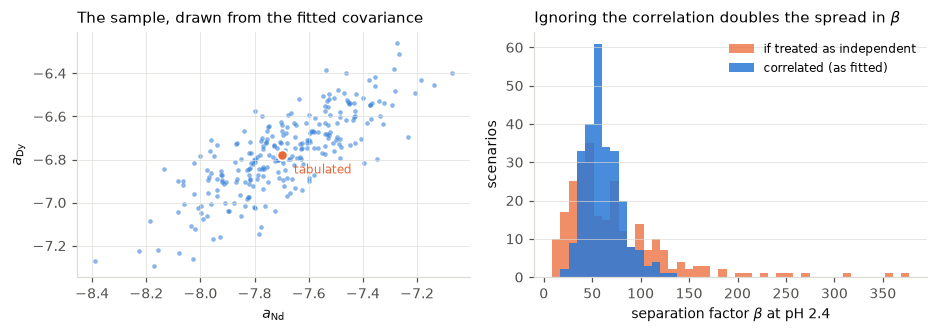

In [4]:
independent = st.ScenarioSet.from_covariance(
    ["a_Nd", "a_Dy"], A_NOM, np.diag(np.diag(COV)), n=256, seed=0)
fig_uncertainty(scenarios, independent, A_NOM, nominal, ELEMENTS);

## 3. The model

A model for `difflow.stochastic` is any pure JAX callable
`model(x, u, theta) -> {name: value}`. Nothing here is special-cased: `x` is the
first stage, `u` the recourse, `theta` one realization of the uncertainty, and
the three dicts are keyed by the names declared in the problem.

In [5]:
def circuit(x, u, theta):
    """One counter-current extraction section, priced.

    x     first stage : n_stages, solvent  -- built once, lived with forever
    u     recourse    : pH                 -- reset each campaign
    theta uncertainty : a_Nd, a_Dy         -- never revealed
    """
    # Read the levers out of one merged dict rather than naming the stage each
    # lives in. The model then does not care which stage a variable is in, and
    # moving pH from `recourse` to `first_stage` -- which is the whole
    # difference between a plant with a control loop and one without -- needs
    # no edit here at all. Section 7 does exactly that.
    lever = {**x, **u}
    solvent = lever["solvent"]

    params = REEExtractorParams(
        n_stages=lever["n_stages"], extractant="D2EHPA", elements=ELEMENTS,
        pH=lever["pH"], extractant_conc=1.0, include_loading=True,
        coefficient_overrides={"Nd": {"a": theta["a_Nd"]},
                               "Dy": {"a": theta["a_Dy"]}},
    )
    feed = make_stream({"H2O": WATER, **FEED}, T=298.15, P=101325.0)
    solv = make_stream({"D2EHPA": 0.25 * solvent, "kerosene": 0.75 * solvent},
                       T=298.15, P=101325.0)
    _, extract, _ = REEExtractor(params)(feed, solv)

    ef = get_flows(extract)
    dy, nd = ef["Dy"], ef["Nd"]
    revenue = dy * MW["Dy"] * 1e-3 * PRICE["Dy"] * HOURS
    cleanup = nd * MW["Nd"] * 1e-3 * CLEANUP * HOURS
    cost = solvent * SOLVENT_COST + lever["n_stages"] * STAGE_COST

    return {"profit": (revenue - cleanup - cost) / 1e6,   # $M/yr
            "purity": dy / (dy + nd + 1e-12),
            "recovery": dy / FEED["Dy"]}


nom = circuit({"n_stages": 6.0, "solvent": 12.0}, {"pH": 2.3},
              dict(zip(["a_Nd", "a_Dy"], A_NOM)))
print({k: round(float(v), 4) for k, v in nom.items()})

{'profit': 130.619, 'purity': 0.8521, 'recovery': 0.7989}


Note `n_stages` is a *continuous* decision. The Kremser expression is
$E^{N+1}$, which is perfectly smooth in $N$, so the optimizer can move it and
you round at the end. Nothing above forces it to an integer.

### The split that is the whole model

| | | |
|---|---|---|
| **First stage** — *here and now* | `n_stages`, `solvent` | one value, shared by every scenario. That sharing **is** non-anticipativity: it is structural, not a constraint that could be written down wrongly. |
| **Recourse** — *wait and see* | `pH` | re-decided per campaign, once the uncertainty is known |
| **Uncertain** | `a_Nd`, `a_Dy` | never revealed |

Is pH legitimately recourse here? A distribution coefficient is *not* observable
— it is a property of the chemistry, identical in every campaign and unknown in
all of them. But the operator does not need to see $D$. They see the raffinate
assay, and they turn pH until it is on target. pH is second stage not because
$D$ was revealed but because its **consequence** was. Section 7 prices exactly
that distinction.

## 4. The problem, and the design you get by ignoring the uncertainty

The specification: Dy purity in the extract at least 0.80, with 90% confidence.
The objective is $\mathrm{CVaR}_{0.9}$ of profit — the mean of the worst decile
of campaigns — because a plant that averages well while occasionally losing
money is not the same plant as one that does not.

In [6]:
PURITY_SPEC, CONFIDENCE = 0.80, 0.90

problem = st.TwoStageProblem(
    model=circuit,
    first_stage={"n_stages": (2.0, 16.0), "solvent": (3.0, 45.0)},
    recourse={"pH": (1.8, 2.8)},
    objective="profit", maximize=True,
    risk=("cvar", 0.9),
    constraints=[("purity", ">=", PURITY_SPEC, CONFIDENCE)],
)
print(problem.describe())

TwoStageProblem: maximize CVaR_0.9[objective] on 'profit'
  first stage (here and now), 2 decisions:
    n_stages            [2, 16]
    solvent             [3, 45]
  recourse (wait and see), 1 decisions per scenario:
    pH                  [1.8, 2.8]
  constraints (1):
    P(purity >= 0.8) >= 0.9 [CVaR surrogate]
  auxiliary variables: 2 (Rockafellar-Uryasev)


In [7]:
options = st.SAAOptions(steps=300, rounds=6, n_starts=2)

t0 = time.time()
deterministic = st.expected_value_solution(problem, scenarios, options=options)
print(f"({time.time() - t0:.1f}s)  design at the nominal coefficients: "
      f"{ {k: round(v, 2) for k, v in deterministic.first_stage.items()} }")

(10.3s)  design at the nominal coefficients: {'n_stages': 3.4, 'solvent': 7.2}


That is the design a study that ignores the uncertainty produces: a small, cheap
section that sits exactly on its purity specification at the tabulated
coefficients. Now build it and run it for a year.

In [8]:
as_built = st.solve_recourse(problem, scenarios, deterministic.first_stage,
                             options=options)
print(as_built.summary())

SAA solution (maximize CVaR_0.9[objective] on 'profit')
  scenarios      256 (normal, seed 0)
  risk value           68.458
  mean                132.936
  sd                  37.3714
  p05 / p95           69.3547 / 181.666
  first stage (one value, every scenario):
    n_stages                     3.4
    solvent                      7.2
  recourse (per scenario):
    variable                    mean         min         max   at bound
    pH                       2.37746     2.15069      2.6608      0.0%
  constraints (scored from the model):
    constraint                                      residual  violated
   *P(purity >= 0.8) >= 0.9 [CVaR surrogate]         0.02244    10.9%
  feasible: False
  value_at_risk           -70.4081
  tail_scenarios              25.6


The operator gets to re-optimize pH in every campaign — full recourse, best
effort — and the section still misses the purity specification about **11% of
the time** against a spec written for 10%, with a profit spread of nearly \$40M.
This is the classic failure of designing on a constraint: a design placed exactly
on a specification spends roughly half its campaigns on the wrong side of it, and
recourse alone cannot rescue a section that is too small to have any room.

## 5. The stochastic design

In [9]:
t0 = time.time()
stochastic = st.solve_saa(problem, scenarios, options=options)
print(f"solved in {time.time() - t0:.1f}s\n")
print(stochastic.summary())

solved in 5.0s

SAA solution (maximize CVaR_0.9[objective] on 'profit')
  scenarios      256 (normal, seed 0)
  risk value          115.678
  mean                142.326
  sd                  12.1567
  p05 / p95           118.037 / 159.406
  first stage (one value, every scenario):
    n_stages                  7.0838
    solvent                  3.33566
  recourse (per scenario):
    variable                    mean         min         max   at bound
    pH                       2.52953      2.3411         2.8      0.4%
  constraints (scored from the model):
    constraint                                      residual  violated
    P(purity >= 0.8) >= 0.9 [CVaR surrogate]       9.235e-07     3.1%
  feasible: True
  value_at_risk           -120.904
  tail_scenarios              25.6


The stochastic design is a *different plant*: roughly twice the stages, less
than half the solvent. That combination is what buys purity — more stages
approach equilibrium, less organic means less Nd dragged across — and it is not
a direction the nominal design was heading in at all.

The result: 3% off spec instead of 11%, and the worst-decile profit roughly
doubles while the spread across campaigns falls by a factor of three.

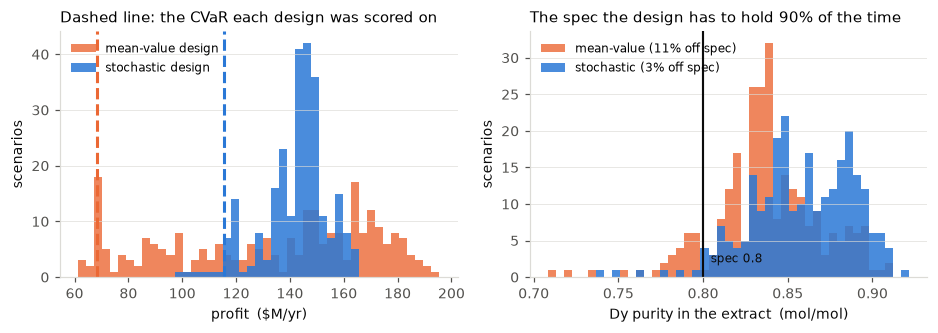

In [10]:
fig_designs(as_built, stochastic, PURITY_SPEC);

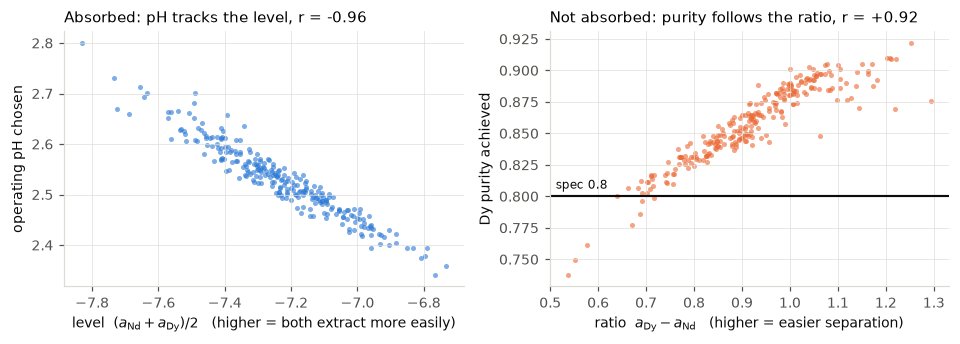

In [11]:
fig_recourse(stochastic, scenarios, PURITY_SPEC);

This is the most informative picture in the notebook, and it is not the one you
would guess. The uncertainty has two directions and the pH loop treats them
completely differently:

|  | absorbed by pH? | drives purity? |
|---|---|---|
| **level**, $(a_{\mathrm{Nd}} + a_{\mathrm{Dy}})/2$ — how strongly *both* metals extract | yes: $r(\mathrm{pH}, \text{level}) = -0.96$ | barely: $r = -0.38$ |
| **ratio**, $a_{\mathrm{Dy}} - a_{\mathrm{Nd}}$ — the separation factor | no: $r(\mathrm{pH}, \text{ratio}) = +0.18$ | almost entirely: $r = +0.92$ |

The operator is running a level-compensation loop, and a very good one: when
the chemistry turns out to extract more strongly than tabulated, pH comes down,
and vice versa, with 93% of the variance in the chosen pH explained by a linear
fit in the two coefficients. That is why EVPI came out at zero — the loop
already does everything advance knowledge of the level would let you do.

But pH cannot change the *ratio*. A campaign that draws a poor separation factor
gets a poor purity and there is no operating move that fixes it. About one
campaign in nine finishes within 0.025 of the specification, and 3% of them
below it — that is the chance constraint doing its job. That risk has to be
carried by the **design** — more stages, less solvent — and carrying it is
exactly the \$47M/yr the VSS measured. The two numbers were never in tension:
recourse handled one direction of the uncertainty and the design had to pay for
the other.

## 6. Was any of this worth doing?

Two classical numbers, and they answer different questions.

$$\mathrm{VSS} = \mathrm{EEV} - \mathrm{SP} \qquad\text{was modelling the uncertainty worth it?}$$

$$\mathrm{EVPI} = \mathrm{SP} - \mathrm{WS} \qquad\text{would measuring it be worth more?}$$

EVPI compares against the unattainable plan that knows each realization in
advance, so it is an **upper bound on what any measurement can possibly be
worth**. That makes it the number to compute before commissioning a
characterization campaign.

In [12]:
t0 = time.time()
report = st.bounds(problem, scenarios, result=stochastic, options=options)
print(f"({time.time() - t0:.1f}s)\n")
print(report.summary())

(9.8s)

Stochastic-programming bounds
  wait and see  (WS)                        115.68
  stochastic    (SP)                       115.678
  mean-value design (EEV)                   68.458
  value of the stochastic solution         47.2202
  expected value of perfect info        0.00135914
  design                    mean-value    stochastic
  n_stages                         3.4        7.0838
  solvent                          7.2       3.33566


**VSS is about \$47M/yr** — that is what running the stochastic program bought
over the nominal design, and it is far more than the study cost.

**EVPI is essentially zero.** Perfect advance knowledge of $a_{\mathrm{Nd}}$ and
$a_{\mathrm{Dy}}$ is worth nothing at all. If a lab had offered to nail those
coefficients down for \$2M, the answer from this run is *don't buy it* — and no
amount of intuition about how uncertain the chemistry is would have told you
that.

The reason is the pH loop. It absorbs the coefficient uncertainty as fast as the
uncertainty arrives, so knowing it in advance adds nothing. Which raises the
obvious question: what is the loop itself worth?

## 7. Recourse and information are substitutes

The same problem with `pH` moved from `recourse` into `first_stage`: a section
run at one fixed operating point, campaign after campaign, whatever the assay
says. The model does not change — only which dict `pH` is read from.

In [13]:
no_recourse = st.TwoStageProblem(
    model=circuit,
    first_stage={"n_stages": (2.0, 16.0), "solvent": (3.0, 45.0),
                 "pH": (1.8, 2.8)},                    # pH is now here-and-now
    objective="profit", maximize=True, risk=("cvar", 0.9),
    constraints=[("purity", ">=", PURITY_SPEC, CONFIDENCE)],
)
t0 = time.time()
rigid = st.bounds(no_recourse, scenarios, options=options)
print(f"({time.time() - t0:.1f}s)\n")
print(rigid.summary())

(13.7s)

Stochastic-programming bounds
  wait and see  (WS)                        115.68
  stochastic    (SP)                      -18.0755
  mean-value design (EEV)                 -26.7672
  value of the stochastic solution         8.69171
  expected value of perfect info           133.755
  design                    mean-value    stochastic
  n_stages                         3.4       9.20721
  solvent                          7.2             3
  pH                               1.9       2.43088


In [14]:
print(f"{'':22s}{'with a pH loop':>16s}{'without one':>16s}")
print(f"{'CVaR_0.9 of profit':22s}{report.stochastic:16.1f}"
      f"{rigid.stochastic:16.1f}")
print(f"{'VSS  ($M/yr)':22s}{report.vss:16.1f}{rigid.vss:16.1f}")
print(f"{'EVPI ($M/yr)':22s}{report.evpi:16.3f}{rigid.evpi:16.1f}")

                        with a pH loop     without one
CVaR_0.9 of profit               115.7           -18.1
VSS  ($M/yr)                      47.2             8.7
EVPI ($M/yr)                     0.001           133.8


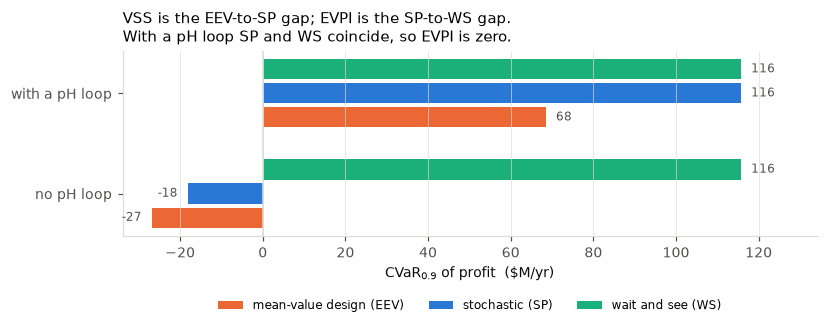

In [15]:
fig_bounds(report, rigid);

Without recourse the section **loses money** at the risk level it is scored on,
and EVPI jumps from nothing to about \$134M/yr.

That is the whole lesson of the two numbers, quantified:

- With a working pH loop, information about $D$ is worthless — the loop already
  handles it. Do not fund the characterization campaign.
- Without one, information is worth \$134M/yr — but so is *the loop*, which is
  the same \$134M and is almost certainly cheaper than resolving the chemistry.

**Recourse and information are substitutes, and the cheap one usually wins.**
Neither number is available from a deterministic study, or from propagating
uncertainty through a fixed design; they exist only once the design itself is
optimized against the distribution.

## 8. Do not trust it until it has been checked

A stochastic program will return a confident answer to a badly posed question.
`check_scenario_health` is the counterpart of `check_delta_health` in
`difflow.planning`: the things that go quietly wrong, each with a number.

In [16]:
health = st.check_scenario_health(problem, scenarios, stochastic)
print(health.summary())

Scenario health: 256 scenarios
  risk value               115.678  +/- 1.86 (sampling)
  half-sample risk         113.408
  CVaR tail                   25.6  scenarios
  first-stage lever             dRisk/dx
  n_stages                      -5.35551
  solvent                        34.5471
  findings: none


Both levers have live gradients — no `clip` or `where` has flattened one into a
dead column — the CVaR tail holds 26 scenarios rather than two, the recourse is
not pinned at a bound, and the half-sample risk sits inside the bootstrap error.

The formal version is the Mak–Morton–Wood replication bound: solve on several
*independent* samples for a bound from the optimistic side, evaluate the
candidate on one large independent sample for a bound from the achievable side,
and report the gap with a confidence limit. It is the only place in the module
that deliberately redraws the sample.

In [17]:
t0 = time.time()
gap = st.optimality_gap(problem, scenarios, stochastic, n_replications=4,
                        n_evaluation=1024, options=options)
print(f"({time.time() - t0:.1f}s)\n")
print(gap.summary())

(32.1s)

SAA optimality gap (4 replications, 1024-scenario evaluation)
  candidate value               115.318
  replication bound             119.629
  gap                           4.31057  +/- 6.64
  95% one-sided limit           19.9348
  i.e. the design is within 19.9348 of the true optimum with 95% confidence.


The bound is loose, and honestly so: with four replications the standard error
is larger than the gap itself. That is a statement about the sample size, not
about the design — and it is exactly the kind of thing that a single confident
number would have hidden. Raise `n_replications` and `n` to tighten it, at
linear cost.

## What to take away

1. **Correlation between fitted coefficients is not a detail.** Treating
   $a_{\mathrm{Nd}}$ and $a_{\mathrm{Dy}}$ as independent doubled the apparent
   uncertainty in the separation factor. Use `ScenarioSet.from_covariance` with
   the covariance your fit actually produced.
2. **A design placed on a specification fails about half the time.** Recourse
   softens that, but cannot fix a section with no room in it.
3. **VSS says whether to keep doing this.** Here, \$47M/yr. A VSS of zero is a
   perfectly good answer too, and finding it early saves the study.
4. **EVPI is the ceiling on what a measurement can be worth**, and it collapses
   when recourse can already absorb the uncertainty. Compute it *before*
   commissioning the campaign.
5. **Check the sample before believing the answer.** Dead levers, an empty CVaR
   tail and saturated recourse all produce confident nonsense.

### Where to go next

- `docs/stochastic.md` — the module, its three implementation choices, and what
  is deliberately out of scope.
- `difflow.flexibility` — when you want a *guarantee* over an envelope rather
  than a probability over a sample. Its `expected_feasibility` is the cheap
  first look at a design you already have.
- `difflow.planning.backoff` — the linear-model answer: propagate the covariance
  onto the constraint and buy `kappa * sigma` of margin. Orders of magnitude
  cheaper, and right whenever the constraint is nearly linear over the spread.
- `difflow.estimation` — where the covariance used here should come from.